In [7]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

In [8]:
# Download real company financial data
print("Downloading data...")
dataset = fetch_ucirepo(id=365)

# Features = 64 financial ratios per company
X = dataset.data.features

# Target = 1 (bankrupt) or 0 (survived)
y = dataset.data.targets.squeeze()

# Combine into one dataframe
df = X.copy()
df['bankrupt'] = y

# Save locally so you never need to download again
df.to_csv('bankruptcy_data.csv', index=False)

# Confirm it worked
print(f"Shape: {df.shape}")
print(f"\nBankrupt companies : {df['bankrupt'].sum()}")
print(f"Healthy companies  : {(df['bankrupt']==0).sum()}")
print(f"\nFirst 5 rows:")
print(df.head())

Shape: (43405, 66)

Bankrupt companies : 2091
Healthy companies  : 41314

First 5 rows:
   year        A1       A2       A3      A4       A5       A6        A7  \
0     1  0.200550  0.37951  0.39641  2.0472  32.3510  0.38825  0.249760   
1     1  0.209120  0.49988  0.47225  1.9447  14.7860  0.00000  0.258340   
2     1  0.248660  0.69592  0.26713  1.5548  -1.1523  0.00000  0.309060   
3     1  0.081483  0.30734  0.45879  2.4928  51.9520  0.14988  0.092704   
4     1  0.187320  0.61323  0.22960  1.4063  -7.3128  0.18732  0.187320   

        A8      A9  ...       A56      A57      A58       A59     A60     A61  \
0  1.33050  1.1389  ...  0.121960  0.39718  0.87804  0.001924  8.4160  5.1372   
1  0.99601  1.6996  ...  0.121300  0.42002  0.85300  0.000000  4.1486  3.2732   
2  0.43695  1.3090  ...  0.241140  0.81774  0.76599  0.694840  4.9909  3.9510   
3  1.86610  1.0571  ...  0.054015  0.14207  0.94598  0.000000  4.5746  3.6147   
4  0.63070  1.1559  ...  0.134850  0.48431  0.86515  0.1

In [ ]:
import pandas as pd
df=pd.read_csv('bankruptcy_data.csv')
print("==SHAPE==")
print(f"rows:{df.shape[0]:,}")
print(f"columns:{df.shape[1]}")






==SHAPE==
rows:43,405
columns:66


In [6]:
print("==missing value top 10 worst columns ")
missing=df.isnull().sum()
missing_pct=(missing/len(df)*100).round(1)
missing_df=pd.DataFrame({'missing': missing,'percent':missing_pct})
print(missing_df[missing_df['missing']>0].sort_values('percent',ascending=False).head(10))



==missing value top 10 worst columns 
     missing  percent
A37    18984     43.7
A21     5854     13.5
A27     2764      6.4
A60     2152      5.0
A45     2147      4.9
A24      922      2.1
A64      812      1.9
A28      812      1.9
A53      812      1.9
A54      812      1.9


In [7]:
print("\n=== CLASS BALANCE ===")
counts = df['bankrupt'].value_counts()
print(f"Healthy  (0): {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)")
print(f"Bankrupt (1): {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)")


=== CLASS BALANCE ===
Healthy  (0): 41,314  (95.2%)
Bankrupt (1): 2,091  (4.8%)


In [8]:
print("\n=== KEY STATISTICS ===")
print(df.describe().round(2))


=== KEY STATISTICS ===
           year        A1        A2        A3        A4           A5  \
count  43405.00  43397.00  43397.00  43397.00  43271.00     43316.00   
mean       2.94      0.04      0.59      0.11      6.31      -385.35   
std        1.28      2.99      5.84      5.44    295.43     61227.97   
min        1.00   -463.89   -430.87   -479.96     -0.40 -11900000.00   
25%        2.00      0.00      0.27      0.02      1.05       -49.08   
50%        3.00      0.05      0.47      0.20      1.57        -1.03   
75%        4.00      0.13      0.69      0.40      2.79        50.63   
max        5.00     94.28    480.96     28.34  53433.00   1250100.00   

             A6        A7        A8        A9  ...         A56       A57  \
count  43397.00  43397.00  43311.00  43396.00  ...    43278.00  43398.00   
mean      -0.06      0.09     12.64      2.65  ...      -26.22     -0.01   
std        7.20      5.71    505.89     62.93  ...     5327.86     13.67   
min     -508.41   -517.

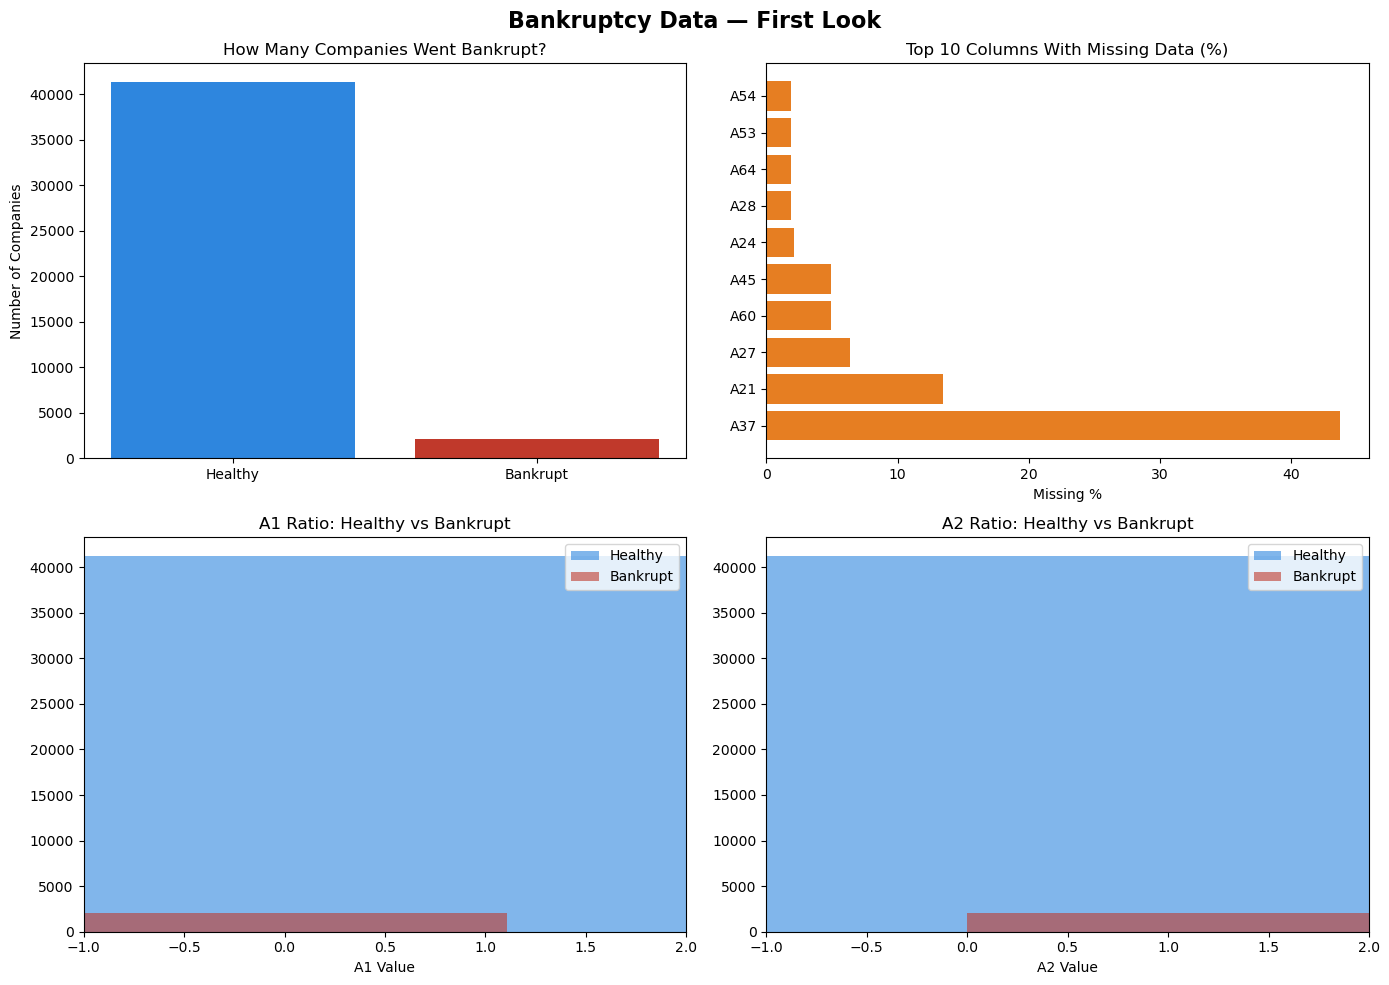

✅ Chart saved as first_look.png


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('bankruptcy_data.csv')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bankruptcy Data — First Look', fontsize=16, fontweight='bold')

# ── Chart 1: Bankrupt vs Healthy ─────────
axes[0,0].bar(['Healthy', 'Bankrupt'], 
               df['bankrupt'].value_counts().values,
               color=['#2E86DE', '#C0392B'])
axes[0,0].set_title('How Many Companies Went Bankrupt?')
axes[0,0].set_ylabel('Number of Companies')

# ── Chart 2: Missing Values ───────────────
missing = (df.isnull().sum() / len(df) * 100)
missing = missing[missing > 0].sort_values(ascending=False).head(10)
axes[0,1].barh(missing.index, missing.values, color='#E67E22')
axes[0,1].set_title('Top 10 Columns With Missing Data (%)')
axes[0,1].set_xlabel('Missing %')

# ── Chart 3: A1 ratio — healthy vs bankrupt
axes[1,0].hist(df[df['bankrupt']==0]['A1'].dropna(), 
               bins=50, alpha=0.6, color='#2E86DE', label='Healthy')
axes[1,0].hist(df[df['bankrupt']==1]['A1'].dropna(), 
               bins=50, alpha=0.6, color='#C0392B', label='Bankrupt')
axes[1,0].set_title('A1 Ratio: Healthy vs Bankrupt')
axes[1,0].set_xlabel('A1 Value')
axes[1,0].legend()
axes[1,0].set_xlim(-1, 2)

# ── Chart 4: A2 ratio — healthy vs bankrupt
axes[1,1].hist(df[df['bankrupt']==0]['A2'].dropna(), 
               bins=50, alpha=0.6, color='#2E86DE', label='Healthy')
axes[1,1].hist(df[df['bankrupt']==1]['A2'].dropna(), 
               bins=50, alpha=0.6, color='#C0392B', label='Bankrupt')
axes[1,1].set_title('A2 Ratio: Healthy vs Bankrupt')
axes[1,1].set_xlabel('A2 Value')
axes[1,1].legend()
axes[1,1].set_xlim(-1, 2)

plt.tight_layout()
plt.savefig('first_look.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as first_look.png")

=== TOP 10 RATIOS THAT SEPARATE HEALTHY vs BANKRUPT ===
ratio  healthy_median  bankrupt_median  difference
  A55        1171.100           86.140    1084.960
  A15         850.270          665.870     184.400
   A5           0.648          -36.663      37.311
  A62          70.041          106.065      36.023
  A32          77.094          108.480      31.386
  A44          54.904           50.894       4.011
  A43          99.248          102.195       2.947
  A47          38.240           35.951       2.289
  A20          35.076           37.239       2.163
  A63           5.186            3.416       1.770


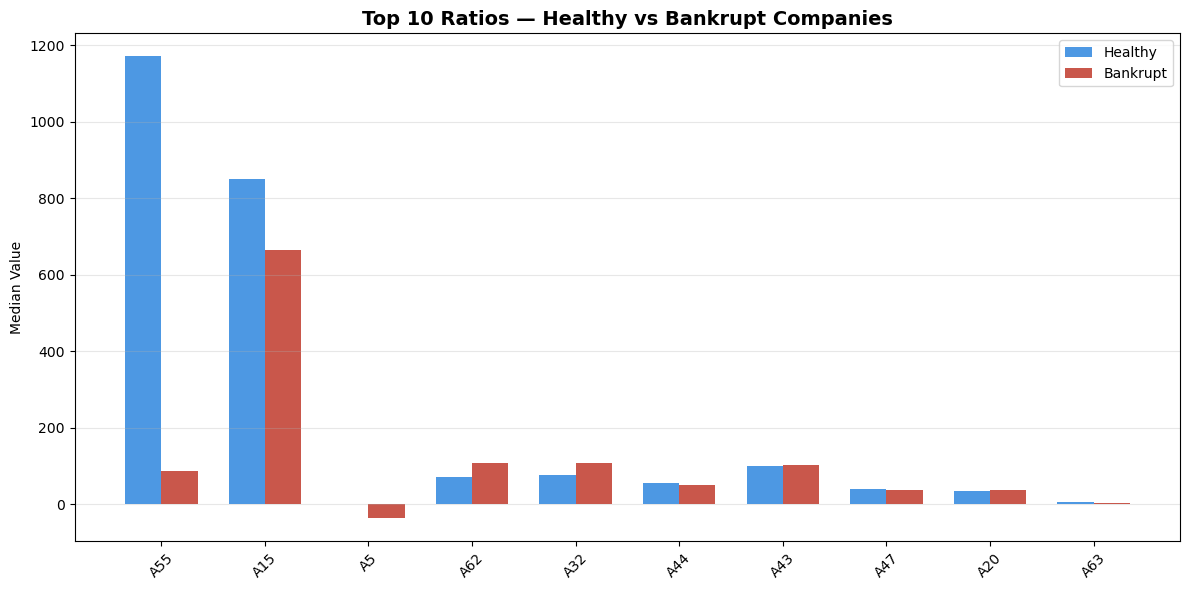


✅ Chart saved as key_ratios.png


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('bankruptcy_data.csv')

# Calculate how different each ratio is 
# between bankrupt and healthy companies
healthy   = df[df['bankrupt'] == 0]
bankrupt  = df[df['bankrupt'] == 1]

# For each column, find the mean difference
ratios = [c for c in df.columns if c not in ['bankrupt', 'year']]

differences = []
for col in ratios:
    h_mean = healthy[col].median()
    b_mean = bankrupt[col].median()
    diff   = abs(h_mean - b_mean)
    differences.append({'ratio': col, 'healthy_median': round(h_mean, 3),
                         'bankrupt_median': round(b_mean, 3), 'difference': round(diff, 3)})

diff_df = pd.DataFrame(differences).sort_values('difference', ascending=False)

print("=== TOP 10 RATIOS THAT SEPARATE HEALTHY vs BANKRUPT ===")
print(diff_df.head(10).to_string(index=False))

# Plot top 10
top10 = diff_df.head(10)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(top10))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], top10['healthy_median'], 
                width, label='Healthy', color='#2E86DE', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], top10['bankrupt_median'], 
                width, label='Bankrupt', color='#C0392B', alpha=0.85)

ax.set_title('Top 10 Ratios — Healthy vs Bankrupt Companies', 
              fontsize=14, fontweight='bold')
ax.set_xticks(list(x))
ax.set_xticklabels(top10['ratio'].values, rotation=45)
ax.set_ylabel('Median Value')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('key_ratios.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart saved as key_ratios.png")

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv('bankruptcy_data.csv')
print(f"Shape before cleaning: {df.shape}")

# ── Step 1: Drop A37 (43% missing — too much to fix) ──
df = df.drop(columns=['A37'])
print("✅ Dropped A37 (43% missing)")

# ── Step 2: Fill remaining missing values ─────────────
# We use median per group — smarter than overall median
# because healthy and bankrupt companies are very different
feature_cols = [c for c in df.columns if c not in ['bankrupt', 'year']]

for col in feature_cols:
    # Fill missing with median of that group (healthy or bankrupt)
    df[col] = df.groupby('bankrupt')[col].transform(
        lambda x: x.fillna(x.median())
    )

print(f"✅ Filled missing values using group median")
print(f"Missing values remaining: {df.isnull().sum().sum()}")

# ── Step 3: Remove extreme outliers ───────────────────
# We use IQR method — standard in finance
def remove_outliers_iqr(df, cols, multiplier=10):
    df_clean = df.copy()
    removed = 0
    for col in cols:
        Q1  = df_clean[col].quantile(0.25)
        Q3  = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & 
                             (df_clean[col] <= upper)]
        removed += before - len(df_clean)
    return df_clean, removed

df_clean, removed = remove_outliers_iqr(df, feature_cols)
print(f"✅ Removed {removed:,} extreme outlier rows")

# ── Step 4: Save clean data ───────────────────────────
df_clean.to_csv('bankruptcy_clean.csv', index=False)

print(f"\nShape after cleaning : {df_clean.shape}")
print(f"Bankrupt companies  : {df_clean['bankrupt'].sum():,}")
print(f"Healthy companies   : {(df_clean['bankrupt']==0).sum():,}")
print("\n✅ Clean data saved as bankruptcy_clean.csv")

Shape before cleaning: (43405, 66)
✅ Dropped A37 (43% missing)
✅ Filled missing values using group median
Missing values remaining: 0
✅ Removed 16,668 extreme outlier rows

Shape after cleaning : (26737, 65)
Bankrupt companies  : 1,145
Healthy companies   : 25,592

✅ Clean data saved as bankruptcy_clean.csv


Training rows : 21,389
Testing rows  : 5,348

=== BASELINE: Logistic Regression ===


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


AUC Score: 0.7276

=== XGBOOST MODEL ===
AUC Score: 0.9820

=== ALTMAN Z-SCORE BENCHMARK ===
AUC Score: 0.6679

=== FINAL COMPARISON ===
Altman Z-Score  : 0.6679
Logistic Reg    : 0.7276
XGBoost         : 0.9820

Your XGBoost beats Altman by: 47.0%


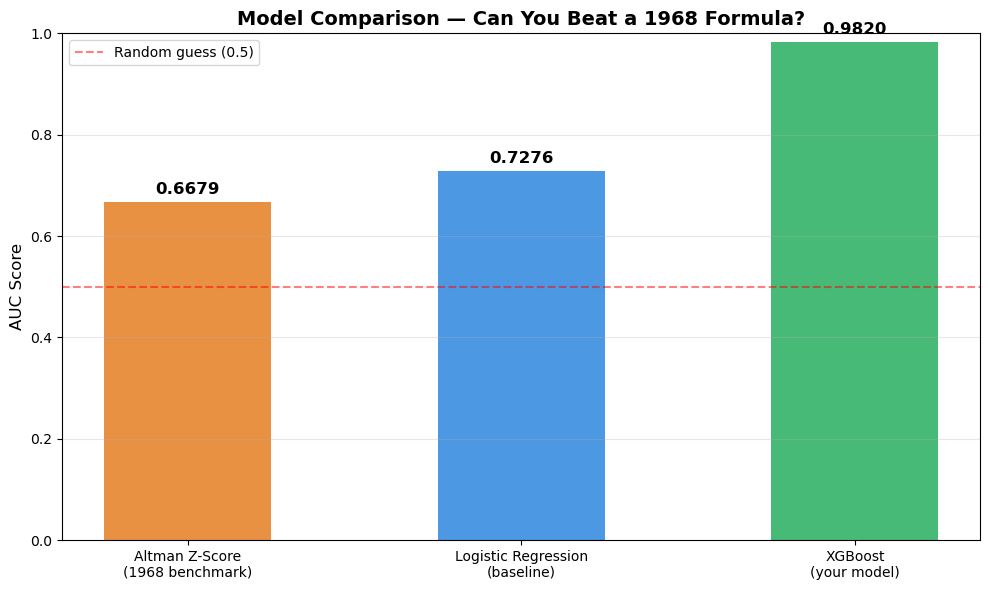


✅ Chart saved as model_comparison.png


In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

df = pd.read_csv('bankruptcy_clean.csv')

# ── Prepare data ──────────────────────────────────────
X = df.drop(columns=['bankrupt', 'year'])
y = df['bankrupt']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training rows : {len(X_train):,}")
print(f"Testing rows  : {len(X_test):,}")

# ── Model 1: Logistic Regression (baseline) ───────────
print("\n=== BASELINE: Logistic Regression ===")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_probs = lr.predict_proba(X_test)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_probs)
print(f"AUC Score: {lr_auc:.4f}")

# ── Model 2: XGBoost ──────────────────────────────────
print("\n=== XGBOOST MODEL ===")
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb.fit(X_train, y_train)
xgb_probs = xgb.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_probs)
print(f"AUC Score: {xgb_auc:.4f}")

# ── Altman Z-Score Benchmark ──────────────────────────
# Simplified version using available columns
# Z = 1.2*X1 + 1.4*X2 + 3.3*X3 + 0.6*X4 + 1.0*X5
# We approximate using closest matching ratios
print("\n=== ALTMAN Z-SCORE BENCHMARK ===")
Z = (1.2 * X_test.iloc[:,0] +
     1.4 * X_test.iloc[:,1] +
     3.3 * X_test.iloc[:,2] +
     0.6 * X_test.iloc[:,3] +
     1.0 * X_test.iloc[:,4])
Z_scaled = (Z - Z.min()) / (Z.max() - Z.min())
altman_auc = roc_auc_score(y_test, 1 - Z_scaled)
print(f"AUC Score: {altman_auc:.4f}")

# ── Compare all three ─────────────────────────────────
print("\n=== FINAL COMPARISON ===")
print(f"Altman Z-Score  : {altman_auc:.4f}")
print(f"Logistic Reg    : {lr_auc:.4f}")
print(f"XGBoost         : {xgb_auc:.4f}")

improvement = ((xgb_auc - altman_auc) / altman_auc * 100)
print(f"\nYour XGBoost beats Altman by: {improvement:.1f}%")

# ── Bar chart comparison ──────────────────────────────
models = ['Altman Z-Score\n(1968 benchmark)', 
          'Logistic Regression\n(baseline)', 
          'XGBoost\n(your model)']
scores = [altman_auc, lr_auc, xgb_auc]
colors = ['#E67E22', '#2E86DE', '#27AE60']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, scores, color=colors, alpha=0.85, width=0.5)
ax.set_ylim(0, 1)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_title('Model Comparison — Can You Beat a 1968 Formula?', 
              fontsize=14, fontweight='bold')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random guess (0.5)')

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', va='bottom', 
            fontweight='bold', fontsize=12)

ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart saved as model_comparison.png")

Calculating SHAP values... (takes 1-2 mins)


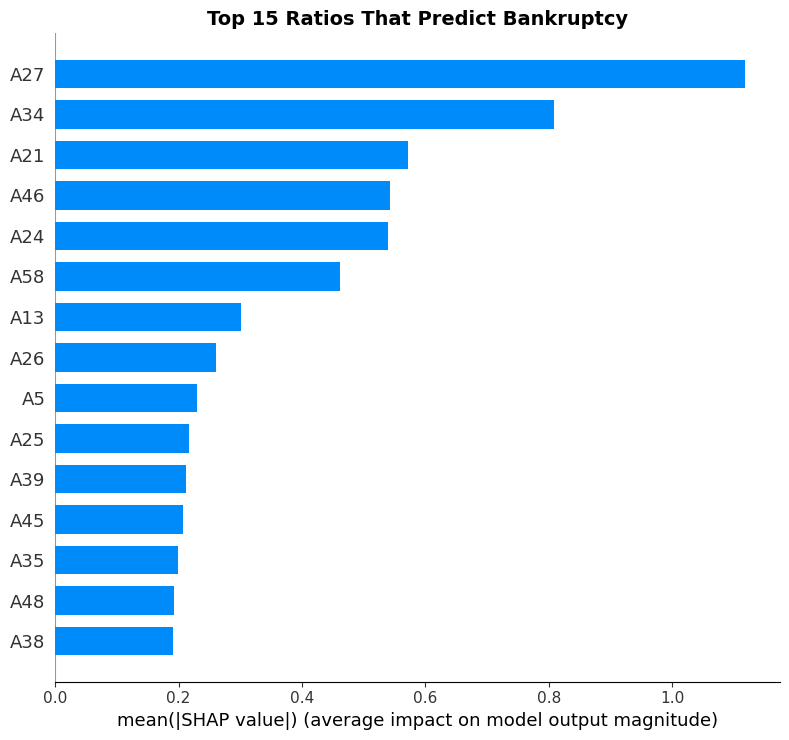

✅ Saved shap_importance.png


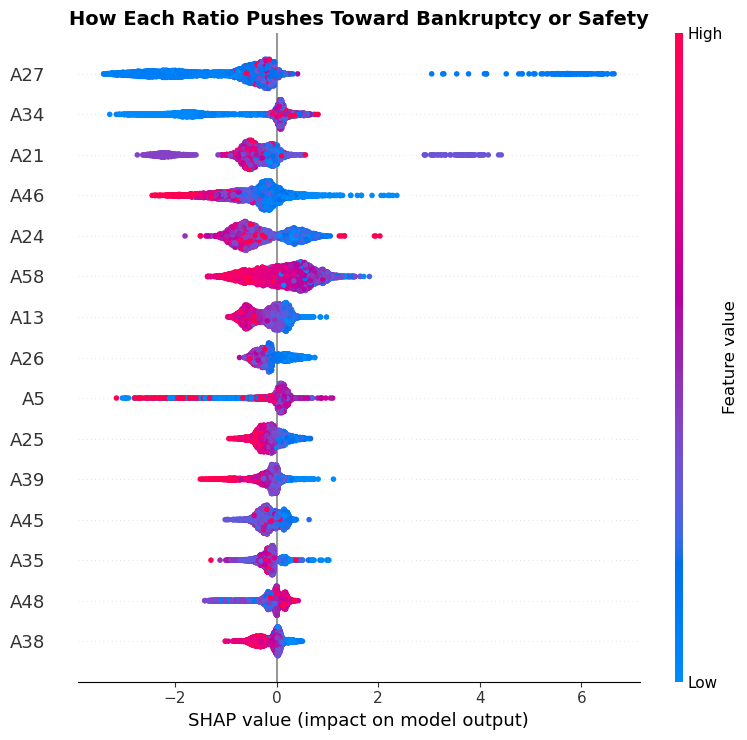

✅ Saved shap_impact.png

=== TOP 10 BANKRUPTCY PREDICTORS ===
feature  importance
    A27    1.118351
    A34    0.808144
    A21    0.570879
    A46    0.542026
    A24    0.538667
    A58    0.461795
    A13    0.300383
    A26    0.260427
     A5    0.230245
    A25    0.216432


In [17]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

df = pd.read_csv('bankruptcy_clean.csv')

X = df.drop(columns=['bankrupt', 'year'])
y = df['bankrupt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train XGBoost again
xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42, eval_metric='auc', verbosity=0
)
xgb.fit(X_train, y_train)

# ── SHAP Explainability ───────────────────────────────
print("Calculating SHAP values... (takes 1-2 mins)")
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# ── Chart 1: Top 15 most important features ───────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, 
                   plot_type='bar', max_display=15,
                   show=False)
plt.title('Top 15 Ratios That Predict Bankruptcy', 
           fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved shap_importance.png")

# ── Chart 2: How each feature affects predictions ─────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, 
                   max_display=15, show=False)
plt.title('How Each Ratio Pushes Toward Bankruptcy or Safety',
           fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved shap_impact.png")

# ── Print top 10 in text ──────────────────────────────
feature_importance = pd.DataFrame({
    'feature':    X_test.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

print("\n=== TOP 10 BANKRUPTCY PREDICTORS ===")
print(feature_importance.head(10).to_string(index=False))